# 01 - Data Quality Assessment
### Student Course Completion Prediction Dataset

This notebook loads the dataset and profiles it: missing values, duplicates, invalid records,
inconsistent formats, outliers, and data type issues. Nothing gets fixed here, that happens in
notebook 02. Every issue found gets logged into a running table and exported as `quality_report.csv`.

**Note on data loading:** the loader below checks, in order: the full CSV already placed in
`data/raw/` (`Course_Completion_Prediction.csv`, 100,000 rows), then a live Kaggle download via
`kagglehub` if that file isn't present, then finally the 200-row sample as a last-resort dry run.
This means the notebook runs correctly whether you have the full CSV sitting locally, only Kaggle
API access, or neither.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## 1. Load the dataset

In [2]:
def load_dataset():
    """Prefer the full local CSV, fall back to a live Kaggle download, then the sample."""
    local_full_path = "../data/raw/Course_Completion_Prediction.csv"
    if os.path.exists(local_full_path):
        df = pd.read_csv(local_full_path)
        print(f"Loaded full dataset from local file: {df.shape[0]} rows, {df.shape[1]} columns")
        return df, "full_local"

    try:
        import kagglehub
        path = kagglehub.dataset_download(
            "nisargpatel344/student-course-completion-prediction-dataset"
        )
        csv_files = [f for f in os.listdir(path) if f.endswith(".csv")]
        df = pd.read_csv(os.path.join(path, csv_files[0]))
        print(f"Loaded full dataset from Kaggle: {df.shape[0]} rows, {df.shape[1]} columns")
        return df, "full_kaggle"
    except Exception as e:
        print(f"Kaggle download not available here ({type(e).__name__}: {e})")
        print("Falling back to the local 200-row sample for a dry run.")
        sample_path = "../data/raw/sample_200.csv"
        df = pd.read_csv(sample_path)
        print(f"Loaded sample dataset: {df.shape[0]} rows, {df.shape[1]} columns")
        return df, "sample"

df, data_source = load_dataset()
print(f"\nData source used in this run: {data_source}")
df.head()

Loaded full dataset from local file: 100000 rows, 40 columns

Data source used in this run: full_local


,Student_ID,Name,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,Course_Name,Category,Course_Level,Course_Duration_Days,Instructor_Rating,Login_Frequency,Average_Session_Duration_Min,Video_Completion_Rate,Discussion_Participation,Time_Spent_Hours,Days_Since_Last_Login,Notifications_Checked,Peer_Interaction_Score,Assignments_Submitted,Assignments_Missed,Quiz_Attempts,Quiz_Score_Avg,Project_Grade,Progress_Percentage,Rewatch_Count,Enrollment_Date,Payment_Mode,Fee_Paid,Discount_Used,Payment_Amount,App_Usage_Percentage,Reminder_Emails_Clicked,Support_Tickets_Raised,Satisfaction_Rating,Completed
0,STU100000,Vihaan Patel,Male,19,Diploma,Student,Indore,Laptop,Medium,C102,Data Analysis with Python,Programming,Intermediate,60,4.7,3,30,55.0,2,0.5,1,6,4.3,8,1,5,80.9,71.2,70.8,0,01-06-2024,Scholarship,No,No,1740,49,3,4,3.5,Completed
1,STU100001,Arjun Nair,Female,17,Bachelor,Student,Delhi,Laptop,Low,C106,Machine Learning A-Z,Programming,Advanced,90,4.6,4,37,84.1,2,0.9,3,5,7.8,4,6,3,78.4,42.5,55.6,2,27-04-2025,Credit Card,Yes,No,6147,86,0,0,4.5,Not Completed
2,STU100002,Aditya Bhardwaj,Female,34,Master,Student,Chennai,Mobile,Medium,C101,Python Basics,Programming,Beginner,45,4.6,5,9,75.6,3,0.5,19,5,6.7,8,2,3,100.0,87.9,78.8,2,20-01-2024,NetBanking,Yes,No,4280,85,1,0,5.0,Completed
3,STU100003,Krishna Singh,Female,29,Diploma,Employed,Surat,Mobile,High,C105,UI/UX Design Fundamentals,Design,Beginner,40,4.4,2,27,63.3,1,7.4,19,9,6.4,0,10,4,59.1,51.4,24.7,4,13-05-2025,UPI,Yes,No,3812,42,2,3,3.8,Completed
4,STU100004,Krishna Nair,Female,19,Master,Self-Employed,Lucknow,Laptop,Medium,C106,Machine Learning A-Z,Programming,Advanced,90,4.6,2,36,86.4,1,0.5,4,7,7.5,5,5,8,84.8,93.0,64.9,4,19-12-2024,Debit Card,Yes,Yes,5486,91,3,0,4.0,Completed


**Important:** if `data_source` prints as `sample` above, the counts and percentages in the rest
of this notebook describe the 200-row sample, not the full dataset. As long as
`Course_Completion_Prediction.csv` is present in `data/raw/`, this notebook runs on the real
100,000-row dataset.

## 2. Basic structure

In [5]:
print("Shape:", df.shape)
print()
df.info()

Shape: (100000, 40)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 40 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Student_ID                    100000 non-null  object 
 1   Name                          100000 non-null  object 
 2   Gender                        100000 non-null  object 
 3   Age                           100000 non-null  int64  
 4   Education_Level               100000 non-null  object 
 5   Employment_Status             100000 non-null  object 
 6   City                          100000 non-null  object 
 7   Device_Type                   100000 non-null  object 
 8   Internet_Connection_Quality   100000 non-null  object 
 9   Course_ID                     100000 non-null  object 
 10  Course_Name                   100000 non-null  object 
 11  Category                      100000 non-null  object 
 12  Course_Level            

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Student_ID,100000,100000,STU100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,100000,300,Ritika Iyer,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,100000,3,Female,50187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,100000.0,NaN,NaN,NaN,25.70959,5.615292,17.0,21.0,25.0,30.0,52.0
Education_Level,100000,5,Bachelor,54956,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Employment_Status,100000,4,Employed,45091,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,100000,15,Indore,6747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Device_Type,100000,3,Mobile,60021,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Connection_Quality,100000,3,Medium,49985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Course_ID,100000,8,C101,16807,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Missing values

Checking every column for nulls, both as a raw count and as a percentage of the dataset, since a
column with 3 missing values out of 200 rows is a very different problem than 3 missing values
out of 100,000.

In [7]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df) * 100).round(2)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
}).sort_values("missing_count", ascending=False)

# Filter for columns with missing values
missing_only = missing_summary[missing_summary["missing_count"] > 0]

if missing_only.empty:
    print("No missing values found in the dataset.")
else:
    display(missing_only)

No missing values found in the dataset.


In [8]:
# Only plot if there are missing values in the dataset
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(14, 5))
    sns.heatmap(df.isnull(), cbar=False, cmap="rocket_r", yticklabels=False)
    plt.title("Missing value pattern across the dataset")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping heatmap: No missing values found in the dataset.")

Skipping heatmap: No missing values found in the dataset.


## 4. Duplicates

In [9]:
full_row_dupes = df.duplicated().sum()
print(f"Full row duplicates: {full_row_dupes}")

if "Student_ID" in df.columns:
    id_dupes = df["Student_ID"].duplicated().sum()
    print(f"Duplicate Student_ID values: {id_dupes}")

Full row duplicates: 0
Duplicate Student_ID values: 0


## 5. Invalid or out-of-range records

Checking fields that have a natural valid range: percentages should sit between 0 and 100, ages
should be plausible for someone taking an online course, ratings should sit within their stated
scale, and the target column should only ever contain the two expected labels.

In [11]:
issues_log = []

def log_issue(column, issue_type, count, total, resolution):
    pct = round(count / total * 100, 2) if total else 0
    issues_log.append({
        "column": column,
        "issue_type": issue_type,
        "row_count": count,
        "pct_of_data": pct,
        "planned_resolution": resolution
    })
    print(f"[{column}] {issue_type}: {count} rows ({pct}%)")

total_rows = len(df)

# Age sanity check
if "Age" in df.columns:
    bad_age = ((df["Age"] < 10) | (df["Age"] > 90)).sum()
    log_issue("Age", "implausible value (<10 or >90)", bad_age, total_rows,
                "cap or flag for manual review in notebook 02")

# Percentage-scale fields should be 0-100
pct_fields = ["Video_Completion_Rate", "Progress_Percentage", "App_Usage_Percentage"]
for col in pct_fields:
    if col in df.columns:
        bad = ((df[col] < 0) | (df[col] > 100)).sum()
        log_issue(col, "out of 0-100 range", bad, total_rows, "cap to [0, 100] in notebook 02")

# Score fields
score_fields = ["Quiz_Score_Avg", "Project_Grade"]
for col in score_fields:
    if col in df.columns:
        bad = ((df[col] < 0) | (df[col] > 100)).sum()
        log_issue(col, "out of 0-100 range", bad, total_rows, "cap to [0, 100] in notebook 02")

# Instructor rating should be within a 1-5 scale
if "Instructor_Rating" in df.columns:
    bad = ((df["Instructor_Rating"] < 1) | (df["Instructor_Rating"] > 5)).sum()
    log_issue("Instructor_Rating", "out of 1-5 range", bad, total_rows, "flag for manual review")

# Negative values where negatives make no sense
non_negative_fields = ["Login_Frequency", "Time_Spent_Hours", "Course_Duration_Days",
                        "Assignments_Submitted", "Assignments_Missed", "Quiz_Attempts",
                        "Payment_Amount", "Support_Tickets_Raised"]
for col in non_negative_fields:
    if col in df.columns:
        bad = (df[col] < 0).sum()
        log_issue(col, "negative value", bad, total_rows, "cap to 0 or investigate in notebook 02")

# Target column sanity
if "Completed" in df.columns:
    valid_labels = {"Completed", "Not Completed"}
    bad = (~df["Completed"].isin(valid_labels)).sum()
    log_issue("Completed", "unexpected label outside Completed/Not Completed", bad, total_rows,
                "investigate and standardize label")

[Age] implausible value (<10 or >90): 0 rows (0.0%)
[Video_Completion_Rate] out of 0-100 range: 0 rows (0.0%)
[Progress_Percentage] out of 0-100 range: 0 rows (0.0%)
[App_Usage_Percentage] out of 0-100 range: 0 rows (0.0%)
[Quiz_Score_Avg] out of 0-100 range: 0 rows (0.0%)
[Project_Grade] out of 0-100 range: 0 rows (0.0%)
[Instructor_Rating] out of 1-5 range: 0 rows (0.0%)
[Login_Frequency] negative value: 0 rows (0.0%)
[Time_Spent_Hours] negative value: 0 rows (0.0%)
[Course_Duration_Days] negative value: 0 rows (0.0%)
[Assignments_Submitted] negative value: 0 rows (0.0%)
[Assignments_Missed] negative value: 0 rows (0.0%)
[Quiz_Attempts] negative value: 0 rows (0.0%)
[Payment_Amount] negative value: 0 rows (0.0%)
[Support_Tickets_Raised] negative value: 0 rows (0.0%)
[Completed] unexpected label outside Completed/Not Completed: 0 rows (0.0%)


## 6. Business-logic consistency checks

These aren't standard data-type errors, they're checks specific to this dataset's business rules.

In [12]:
# Fee_Paid says No but Payment_Amount is greater than 0
if {"Fee_Paid", "Payment_Amount"}.issubset(df.columns):
    quirk = ((df["Fee_Paid"] == "No") & (df["Payment_Amount"] > 0)).sum()
    log_issue("Fee_Paid / Payment_Amount", "Fee_Paid=No but Payment_Amount>0", quirk, total_rows,
                "not an error - confirm this maps to Scholarship payment mode, document as a business rule, do not overwrite")

    if quirk > 0:
        mode_breakdown = df[(df["Fee_Paid"] == "No") & (df["Payment_Amount"] > 0)]["Payment_Mode"].value_counts()
        print("\nPayment mode breakdown for that quirk:")
        print(mode_breakdown)

# Assignments submitted + missed shouldn't exceed a sane total
if {"Assignments_Submitted", "Assignments_Missed"}.issubset(df.columns):
    total_assignments = df["Assignments_Submitted"] + df["Assignments_Missed"]
    print("\nAssignments_Submitted + Assignments_Missed distribution:")
    print(total_assignments.describe())

# Completed vs Progress_Percentage mismatch
if {"Completed", "Progress_Percentage"}.issubset(df.columns):
    mismatch = ((df["Completed"] == "Completed") & (df["Progress_Percentage"] < 50)).sum()
    completed_total = (df["Completed"] == "Completed").sum()
    log_issue("Progress_Percentage / Completed", "Completed=Completed but Progress_Percentage<50", 
            mismatch, completed_total,"not a data error - investigate in EDA whether Quiz_Score_Avg/Project_Grade drive completion instead of Progress_Percentage")

[Fee_Paid / Payment_Amount] Fee_Paid=No but Payment_Amount>0: 10039 rows (10.04%)

Payment mode breakdown for that quirk:
Payment_Mode
Scholarship    10039
Name: count, dtype: int64

Assignments_Submitted + Assignments_Missed distribution:
count    100000.000000
mean          9.898880
std           0.301489
min           9.000000
25%          10.000000
50%          10.000000
75%          10.000000
max          10.000000
dtype: float64
[Progress_Percentage / Completed] Completed=Completed but Progress_Percentage<50: 14342 rows (29.25%)


## 7. Data type and format issues

In [13]:
# Enrollment_Date stored as text
if "Enrollment_Date" in df.columns:
    sample_dates = df["Enrollment_Date"].head(3).tolist()
    print("Enrollment_Date sample values:", sample_dates)
    print("Current dtype:", df["Enrollment_Date"].dtype)

    try:
        parsed = pd.to_datetime(df["Enrollment_Date"], format="%d-%m-%Y", errors="coerce")
        unparseable = parsed.isnull().sum()
        log_issue("Enrollment_Date", "stored as text, needs datetime parsing",
                    len(df), total_rows, "parse with pd.to_datetime(format='%d-%m-%Y') in notebook 02")
        if unparseable > 0:
            print(f"Warning: {unparseable} rows did not parse with the dd-mm-yyyy format, needs a closer look")
    except Exception as e:
        print("Date parsing issue:", e)

Enrollment_Date sample values: ['01-06-2024', '27-04-2025', '20-01-2024']
Current dtype: object
[Enrollment_Date] stored as text, needs datetime parsing: 100000 rows (100.0%)


In [14]:
# Categorical formatting consistency (casing, whitespace, near-duplicate labels)
categorical_cols = df.select_dtypes(include="object").columns.tolist()
for col in ["Student_ID", "Name"]:
    if col in categorical_cols:
        categorical_cols.remove(col)

for col in categorical_cols:
    values = df[col].dropna().astype(str)
    has_whitespace_issue = (values != values.str.strip()).sum()
    lowered = values.str.lower().str.strip()
    unique_raw = values.nunique()
    unique_normalized = lowered.nunique()
    if unique_raw != unique_normalized or has_whitespace_issue > 0:
        log_issue(col, "inconsistent casing/whitespace across category labels",
                    has_whitespace_issue, total_rows, "standardize casing and strip whitespace in notebook 02")

## 8. Outlier detection (IQR method)

In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "Age" in numeric_cols:
    pass  # keep Age in the scan, it's still worth checking

outlier_summary = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({"column": col, "lower_bound": round(lower, 2),
                                "upper_bound": round(upper, 2), "outlier_count": n_outliers,
                                "outlier_pct": round(n_outliers / total_rows * 100, 2)})
    if n_outliers > 0:
        log_issue(col, "statistical outlier (IQR method)", n_outliers, total_rows,
                    "review in notebook 02, cap only if it looks like a data entry error rather than real behavior")

outlier_df = pd.DataFrame(outlier_summary).sort_values("outlier_count", ascending=False)
outlier_df

[Age] statistical outlier (IQR method): 147 rows (0.15%)
[Login_Frequency] statistical outlier (IQR method): 374 rows (0.37%)
[Average_Session_Duration_Min] statistical outlier (IQR method): 582 rows (0.58%)
[Discussion_Participation] statistical outlier (IQR method): 1366 rows (1.37%)
[Time_Spent_Hours] statistical outlier (IQR method): 1102 rows (1.1%)
[Days_Since_Last_Login] statistical outlier (IQR method): 4048 rows (4.05%)
[Notifications_Checked] statistical outlier (IQR method): 1133 rows (1.13%)
[Peer_Interaction_Score] statistical outlier (IQR method): 323 rows (0.32%)
[Assignments_Submitted] statistical outlier (IQR method): 354 rows (0.35%)
[Assignments_Missed] statistical outlier (IQR method): 431 rows (0.43%)
[Quiz_Attempts] statistical outlier (IQR method): 765 rows (0.76%)
[Quiz_Score_Avg] statistical outlier (IQR method): 311 rows (0.31%)
[Project_Grade] statistical outlier (IQR method): 356 rows (0.36%)
[Progress_Percentage] statistical outlier (IQR method): 466 rows (

,column,lower_bound,upper_bound,outlier_count,outlier_pct
21,Support_Tickets_Raised,-1.50,2.50,6193,6.19
8,Days_Since_Last_Login,-11.00,21.00,4048,4.05
6,Discussion_Participation,-2.00,6.00,1366,1.37
20,Reminder_Emails_Clicked,-2.00,6.00,1291,1.29
17,Rewatch_Count,-2.00,6.00,1259,1.26
9,Notifications_Checked,-0.50,11.50,1133,1.13
7,Time_Spent_Hours,-8.05,14.75,1102,1.10
13,Quiz_Attempts,-2.50,9.50,765,0.76
22,Satisfaction_Rating,2.20,6.20,582,0.58
4,Average_Session_Duration_Min,6.00,62.00,582,0.58


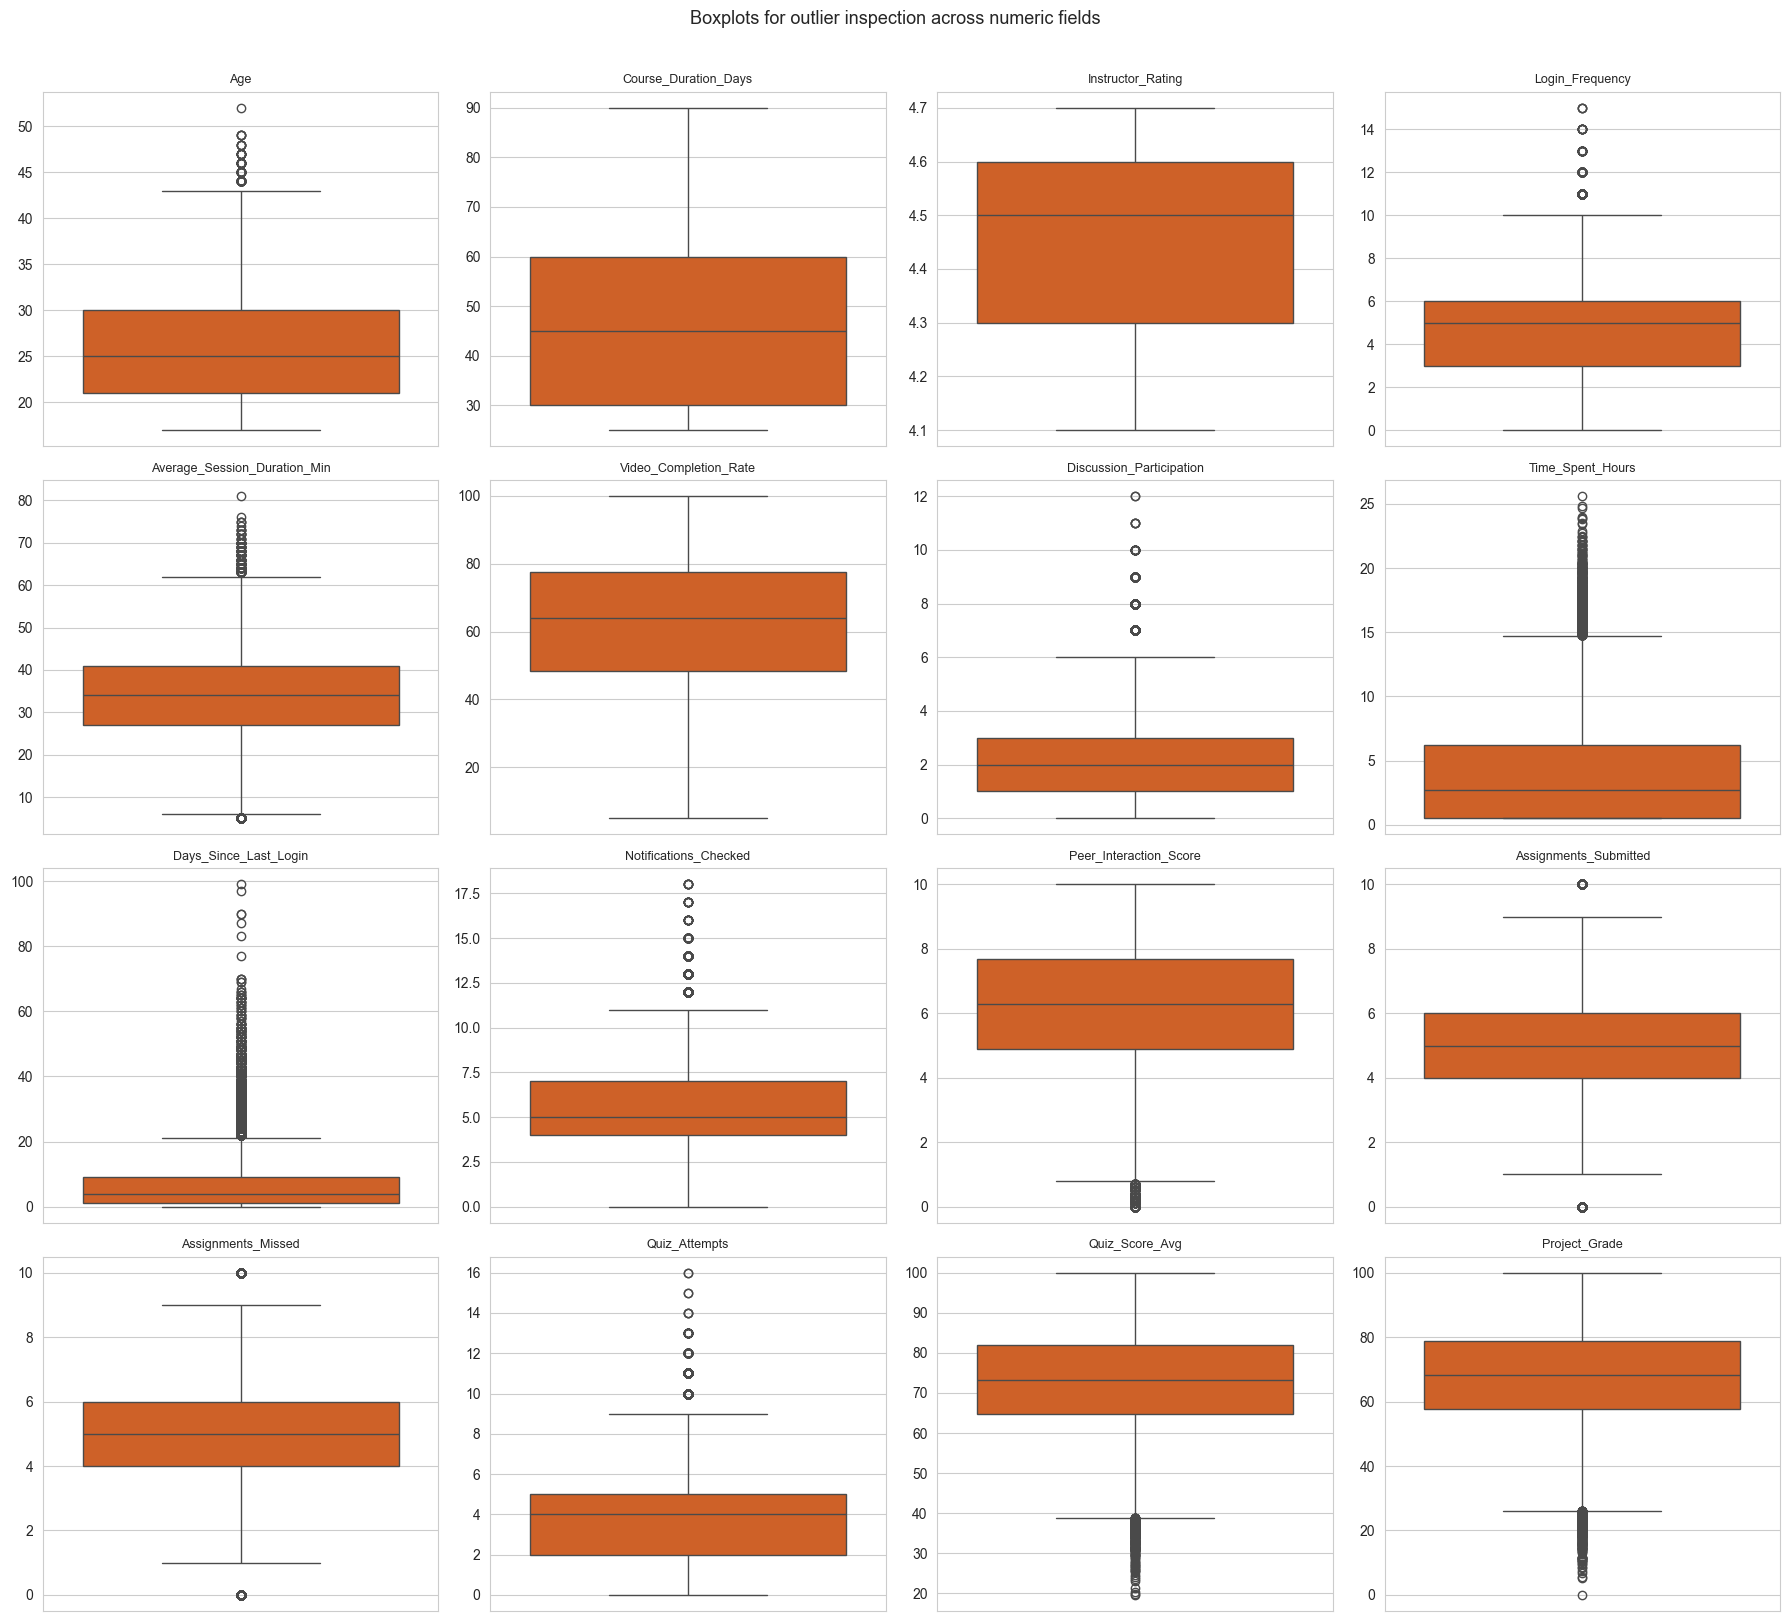

In [16]:
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:16]):
    sns.boxplot(y=df[col], ax=axes[i], color="#ea580c")
    axes[i].set_title(col, fontsize=9)
    axes[i].set_ylabel("")
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle("Boxplots for outlier inspection across numeric fields", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 9. Quality report export

Everything logged above, compiled into a single table and saved as `quality_report.csv`.

In [17]:
quality_report = pd.DataFrame(issues_log)
print(f"Total issues logged: {len(quality_report)}")
quality_report

Total issues logged: 38


,column,issue_type,row_count,pct_of_data,planned_resolution
0,Age,implausible value (<10 or >90),0,0.00,cap or flag for manual review in notebook 02
1,Video_Completion_Rate,out of 0-100 range,0,0.00,"cap to [0, 100] in notebook 02"
2,Progress_Percentage,out of 0-100 range,0,0.00,"cap to [0, 100] in notebook 02"
3,App_Usage_Percentage,out of 0-100 range,0,0.00,"cap to [0, 100] in notebook 02"
4,Quiz_Score_Avg,out of 0-100 range,0,0.00,"cap to [0, 100] in notebook 02"
5,Project_Grade,out of 0-100 range,0,0.00,"cap to [0, 100] in notebook 02"
6,Instructor_Rating,out of 1-5 range,0,0.00,flag for manual review
7,Login_Frequency,negative value,0,0.00,cap to 0 or investigate in notebook 02
8,Time_Spent_Hours,negative value,0,0.00,cap to 0 or investigate in notebook 02
9,Course_Duration_Days,negative value,0,0.00,cap to 0 or investigate in notebook 02


In [18]:
os.makedirs("../reports", exist_ok=True)
quality_report.to_csv("../reports/quality_report.csv", index=False)
print("Saved to ../reports/quality_report.csv")

Saved to ../reports/quality_report.csv


## Summary

This notebook found and logged, on whatever dataset was loaded above (sample or full):
- missing value pattern (if any)
- duplicate rows and IDs
- out-of-range and negative values across numeric fields
- two genuine business-logic quirks: the Scholarship / Fee_Paid mismatch, and the
  Progress_Percentage / Completed mismatch (this second one is a lead worth chasing in the EDA
  notebook, not just a cleanup item)
- text-stored dates needing parsing
- categorical formatting inconsistencies
- statistical outliers per numeric column

Next: `02_data_cleaning_preprocessing.ipynb` picks up `quality_report.csv` and resolves each item.